<div style="background: linear-gradient(135deg, #8a0000, #c0392b); padding: 40px 30px; border-radius: 12px; text-align: center;">
  <h1 style="color: white; font-size: 2.4em; margin: 0;">📊 Data Visualization</h1>
  <h2 style="color: #ffcccc; font-size: 1.3em; margin: 10px 0 0 0; font-weight: normal;">with Matplotlib & Seaborn</h2>
  <hr style="border-color: rgba(255,255,255,0.3); margin: 20px 0;">
  <p style="color: #ffaaaa; margin: 0;">IEEE SSCS — AI Sub-Team &nbsp;|&nbsp; Prepared by <strong style='color:white'>Omar Ashraf</strong></p>
</div>

## 🗺️ What You'll Learn

| # | Topic |
|---|-------|
| 1 | Line Plot |
| 2 | Scatter Plot |
| 3 | Styling Graphs |
| 4 | Distribution Plots — Histogram, KDE, ECDF |
| 5 | Bar Plot |
| 6 | Distribution Comparison — Box Plot & Violin Plot |
| 7 | Heatmap |
| 8 | Multiple Graphs with Subplots (OOP API) |
| 9 | Seaborn vs Matplotlib — When to Use What |

## 📦 Datasets Used
- **Custom dataset** — Apple stock (hand-crafted for simplicity)
- **Iris** — Flower petal/sepal measurements across 3 species
- **Tips** — Restaurant bill and tip data
- **Flights** — Monthly passenger counts from 1949–1960

## 🎯 Goals
By the end of this notebook you should be able to:
- Create and customize any common chart type in Matplotlib and Seaborn
- Choose the **right chart** for your data and question
- Use **visualization to explore and understand data**, not just display it

---

## ⚙️ Setup & Imports

Run this cell first. It imports everything we'll need for the entire notebook.

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


---

# Part 1 — Line Plot

> **When to use:** Showing how a value changes over time or a continuous variable.

We'll use a simple hand-crafted dataset about apple stock over the years.
We'll build the same chart **twice** — first with Matplotlib, then with Seaborn — so you can compare the two approaches.

In [2]:
# Our simple custom dataset
apples = [40, 50, 60, 10, 100, 50, 30]
years  = [1995, 2000, 2005, 2010, 2015, 2020, 2025]

### 1a — Line Plot with Matplotlib

The **functional API**: call `plt.something()` for everything.  
Simple and fast, but less flexible for complex layouts.

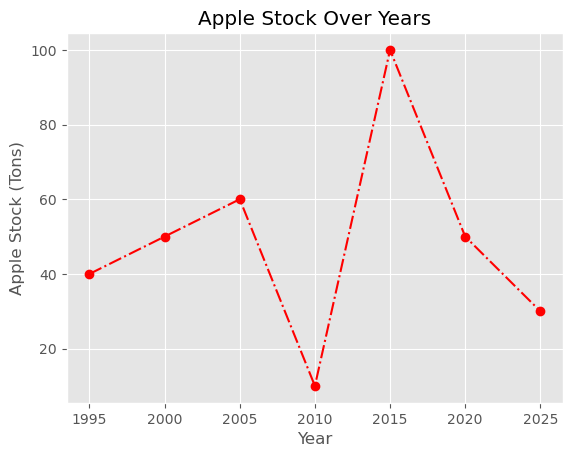

In [3]:
plt.style.use("ggplot")  # Apply a clean built-in style

plt.plot(
    years, apples,
    marker="o",       # Show a dot at each data point
    linestyle="-.",   # Dash-dot line style
    color="red"
)

plt.title("Apple Stock Over Years")
plt.xlabel("Year")
plt.ylabel("Apple Stock (Tons)")
plt.grid(True)
plt.show()

### 1b — Line Plot with Seaborn

Seaborn works best with a **DataFrame** (not raw lists).  
It automatically handles axis labels from column names.

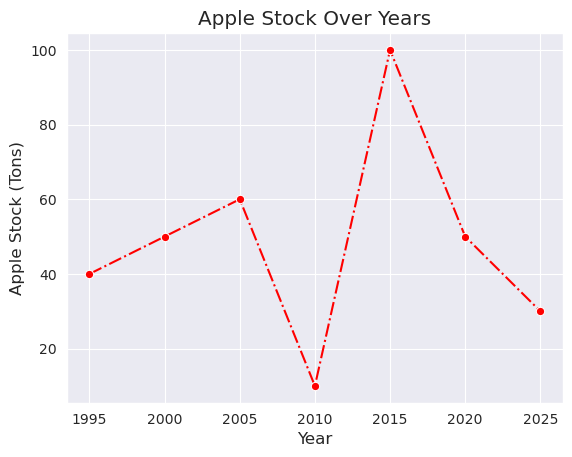

In [4]:
# Convert to a DataFrame so Seaborn can read column names
apples_df = pd.DataFrame({
    "Year": years,
    "Apple Stock (Tons)": apples
})

sns.set_style("darkgrid")  # Seaborn's own style system

sns.lineplot(
    data=apples_df,
    x="Year",
    y="Apple Stock (Tons)",
    marker="o",
    linestyle="-.",
    color="red"
)

plt.title("Apple Stock Over Years")
plt.grid(True)
plt.show()

> 💡 **Matplotlib vs Seaborn for line plots:**  
> Both produce similar results. Use **Matplotlib** when you want full manual control.  
> Use **Seaborn** when you're working with a DataFrame and want built-in statistical features (e.g. confidence intervals).

---

# Part 2 — Scatter Plot

> **When to use:** Exploring the **relationship between two numerical variables**.  
> The `hue` parameter lets you add a third variable (e.g. category) using color.

We'll load the classic **Iris dataset** — 150 flower samples from 3 species.

In [5]:
# Load Iris — built into Seaborn, no download needed
iris_df = sns.load_dataset("iris")

print(iris_df.head())
print("\nSpecies:", iris_df["species"].unique())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Species: ['setosa' 'versicolor' 'virginica']


### 2a — Scatter Plot with Seaborn

One line, automatic color coding by species.

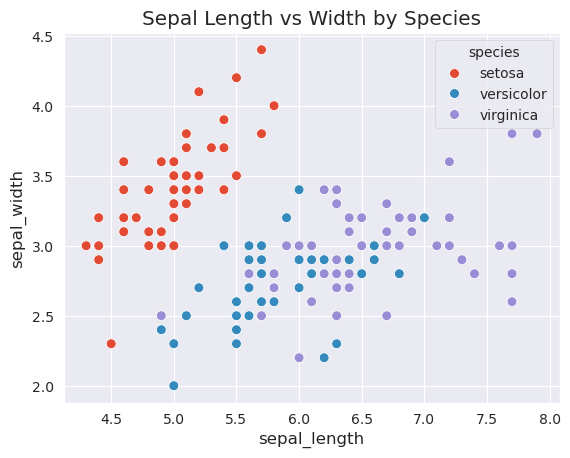

In [10]:
sns.set_style("darkgrid") #default is "darkgrid" try changing to see what happens

sns.scatterplot(
    data=iris_df,
    x="sepal_length",
    y="sepal_width",
    hue="species",   # Color each point by species — Seaborn handles the legend
    s=50             # Dot size
)

plt.title("Sepal Length vs Width by Species")
plt.show()

### 2b — Scatter Plot with Matplotlib

More verbose — you manually filter each species and assign colors.

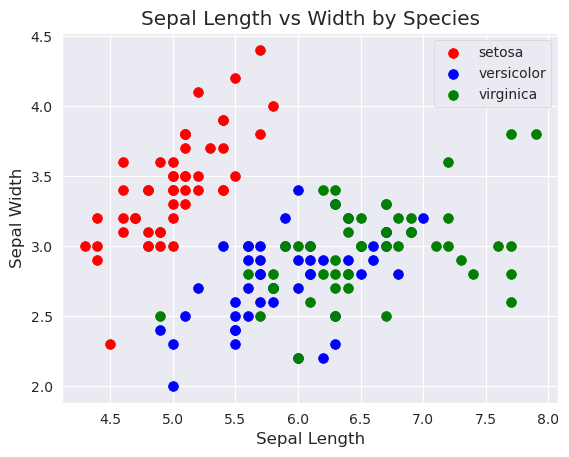

In [11]:
# Filter each species into its own DataFrame
setosa_df     = iris_df[iris_df.species == "setosa"]
versicolor_df = iris_df[iris_df.species == "versicolor"]
virginica_df  = iris_df[iris_df.species == "virginica"]

# Plot each group manually
plt.scatter(setosa_df.sepal_length,     setosa_df.sepal_width,     color="red",   label="setosa",     s=50)
plt.scatter(versicolor_df.sepal_length, versicolor_df.sepal_width, color="blue",  label="versicolor", s=50)
plt.scatter(virginica_df.sepal_length,  virginica_df.sepal_width,  color="green", label="virginica",  s=50)

plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("Sepal Length vs Width by Species")
plt.legend()
plt.show()

> 💡 Seaborn's `hue=` does the filtering and coloring for you automatically.  
> With Matplotlib you have full control, but you write a lot more code.

---

# Part 3 — Distribution Plots

> **When to use:** Understanding the **shape and spread** of a single variable.  
> These three plots answer: *What values are most common? How spread out is the data? How does it accumulate?*

We'll use the **Tips dataset** — real restaurant data with bill amounts, tips, and metadata.

In [12]:
tips_df = sns.load_dataset("tips")
tips_df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


### 3a — Histogram (`histplot`)

Splits data into bins and counts how many values fall in each.  
`kde=True` overlays a smooth density curve on top.

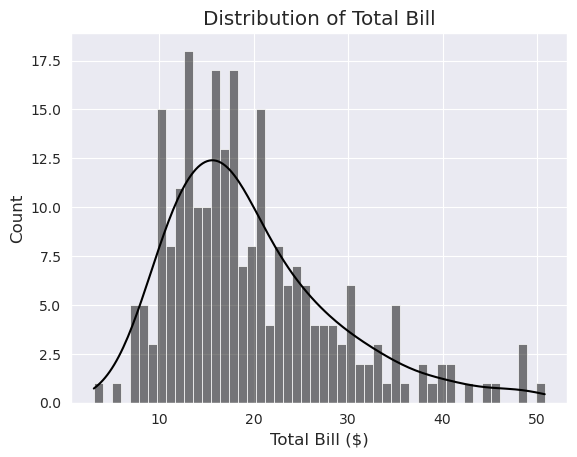

In [16]:
sns.histplot(
    data=tips_df,
    x="total_bill",
    bins=50,       # Number of buckets
    kde=True,      # Overlay a smooth KDE curve
    color="black"
)

plt.title("Distribution of Total Bill")
plt.xlabel("Total Bill ($)")
plt.ylabel("Count")
plt.show()

### 3b — KDE Plot (`kdeplot`)

A smooth estimate of the probability density — no bins, just a continuous curve.  
Great for comparing distributions across groups without the noise of binning.

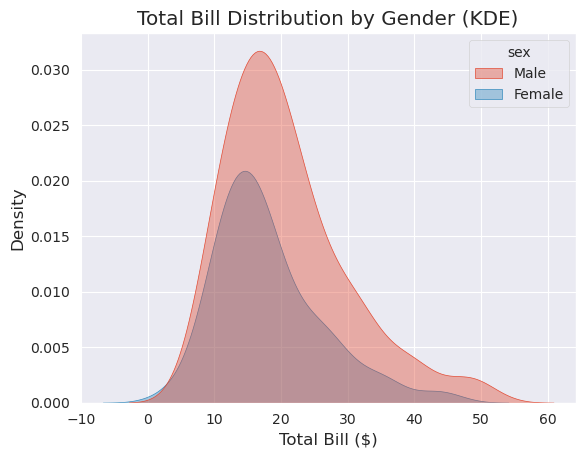

In [17]:
sns.kdeplot(
    data=tips_df,
    x="total_bill",
    hue="sex",    # Compare distribution by gender
    fill=True,    # Fill area under the curve
    alpha=0.4     # Transparency so both curves are visible
)

plt.title("Total Bill Distribution by Gender (KDE)")
plt.xlabel("Total Bill ($)")
plt.show()

### 3c — ECDF Plot (`ecdfplot`)

Shows the **cumulative proportion** of data up to each value.  
Read it as: *"X% of bills were below $Y".*

In [ ]:
sns.ecdfplot(
    data=tips_df,
    x="total_bill",
    hue="day",    # One curve per day of the week
    color="black"
)

plt.title("Cumulative Bill Distribution by Day (ECDF)")
plt.xlabel("Total Bill ($)")
plt.ylabel("Proportion")
plt.show()

> 💡 **Quick Guide — which distribution plot to use?**
> | Plot | Best for |
> |------|----------|
> | `histplot` | Raw counts, seeing the actual shape |
> | `kdeplot` | Smooth comparison across groups |
> | `ecdfplot` | Answering "what % of values are below X?" |

---

# Part 4 — Bar Plot

> **When to use:** Comparing an **aggregated value** (like a mean) across categories.  
> `hue` adds a second categorical dimension — here, smoker vs non-smoker.

In [ ]:
sns.barplot(
    data=tips_df,
    x="day",
    y="total_bill",
    hue="smoker"   # Split each day's bar by smoker status
)

plt.title("Average Total Bill per Day — Smoker vs Non-Smoker")
plt.xlabel("Day")
plt.ylabel("Average Total Bill ($)")
plt.show()

> 💡 The error bars on each column show a **confidence interval** — Seaborn computes this automatically.  
> It tells you how reliable the mean estimate is given the sample size.

---

# Part 5 — Distribution Comparison

> **When to use:** Comparing how a value is distributed **across multiple groups** simultaneously.  
> Box and Violin plots go deeper than bar charts — they show spread, outliers, and shape, not just the mean.

### 5a — Box Plot

In [ ]:
sns.boxplot(
    data=tips_df,
    x="day",
    y="total_bill",
    hue="smoker"
)

plt.title("Bill Distribution per Day — Box Plot")
plt.xlabel("Day")
plt.ylabel("Total Bill ($)")
plt.show()

> 💡 **Reading a box plot:**
> - The **box** spans the middle 50% of the data (IQR: Q1 to Q3)
> - The **line inside** is the median
> - The **whiskers** extend to the min/max (within 1.5× IQR)
> - **Dots** beyond the whiskers are outliers

### 5b — Violin Plot

In [ ]:
sns.violinplot(
    data=tips_df,
    x="day",
    y="total_bill",
    hue="smoker"
)

plt.title("Bill Distribution per Day — Violin Plot")
plt.xlabel("Day")
plt.ylabel("Total Bill ($)")
plt.show()

> 💡 A violin plot is essentially a **KDE plot rotated and mirrored** around a box plot.  
> Where the violin is **wider**, more data points exist at that value.  
> Use violin plots when the **shape** of the distribution matters, not just the summary stats.

---

# Part 6 — Heatmap

> **When to use:** Visualizing a **matrix of values** — correlations, time patterns, pivot tables.  
> Color encodes magnitude: darker = higher (or lower, depending on the colormap).

We'll use the **Flights dataset** — passenger counts across months (rows) and years (columns).

In [ ]:
# Load and inspect the raw data first
flights_raw = sns.load_dataset("flights")
print(flights_raw.head())

In [ ]:
# pivot() reshapes the data from long format → matrix format
# rows = months, columns = years, values = passenger count
flights_df = flights_raw.pivot(index="month", columns="year", values="passengers")

flights_df.head()

In [ ]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    flights_df,
    annot=True,       # Print the actual number in each cell
    fmt="d",          # Format numbers as integers (no decimals)
    cmap="YlGnBu"     # Color palette: yellow → green → blue
)

plt.title("Monthly Flight Passengers (1949–1960)")
plt.xlabel("Year")
plt.ylabel("Month")
plt.show()

> 💡 Notice the clear **seasonal pattern** — summer months (Jun/Jul/Aug) are always the darkest.  
> This is what visualization is for: patterns that would be invisible in raw numbers jump out immediately.

---

# Part 7 — Subplots & the OOP API

So far we've used the **functional API** (`plt.plot()`, `plt.show()`).  
For multiple charts in one figure, we switch to the **Object-Oriented (OOP) API**.

> **The key idea:**  
> `fig, ax = plt.subplots(rows, cols)` gives you a `fig` (the whole canvas) and `ax` (individual chart slots).  
> You then call methods directly on each `ax` slot instead of `plt`.

| Functional API | OOP API equivalent |
|----------------|--------------------|
| `plt.title()` | `ax.set_title()` |
| `plt.xlabel()` | `ax.set_xlabel()` |
| `plt.ylabel()` | `ax.set_ylabel()` |

In [ ]:
# Create a figure with 2 rows, 1 column
fig, ax = plt.subplots(2, 1, figsize=(10, 8))

# ── Top chart: Apple stock line plot ─────────────────────────────
apples = [40, 50, 60, 10, 100, 50, 30]
years  = [1995, 2000, 2005, 2010, 2015, 2020, 2025]

ax[0].plot(years, apples, marker="o", linestyle="-.", color="red")
ax[0].set_title("Apple Stock Over Years")
ax[0].set_xlabel("Year")
ax[0].set_ylabel("Apple Stock (Tons)")
ax[0].grid(True)

# ── Bottom chart: Flights line plot (using Seaborn with ax=) ─────
# Notice: sns charts accept ax= to target a specific subplot slot
sns.lineplot(data=flights_df, ax=ax[1])
ax[1].set_title("Monthly Flight Passengers Over Years")
ax[1].set_xlabel("Month")
ax[1].set_ylabel("Number of Passengers")

plt.tight_layout()  # Automatically adjusts spacing so charts don't overlap
plt.show()

### 2×2 Subplot Grid Example

For a 2D grid, `ax` becomes a 2D array — access cells with `ax[row, col]`.

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

# ── [0, 0] Line Plot ─────────────────────────────────────────────
ax[0, 0].plot(years, apples, marker="o", color="red")
ax[0, 0].set_title("Line Plot — Apple Stock")
ax[0, 0].set_xlabel("Year")
ax[0, 0].set_ylabel("Stock (Tons)")

# ── [0, 1] Scatter Plot ──────────────────────────────────────────
sns.scatterplot(
    data=iris_df, x="sepal_length", y="sepal_width",
    hue="species", s=40, ax=ax[0, 1]
)
ax[0, 1].set_title("Scatter Plot — Iris Species")

# ── [1, 0] Bar Plot ──────────────────────────────────────────────
sns.barplot(
    data=tips_df, x="day", y="total_bill",
    hue="smoker", ax=ax[1, 0]
)
ax[1, 0].set_title("Bar Plot — Avg Bill by Day")
ax[1, 0].set_xlabel("Day")
ax[1, 0].set_ylabel("Avg Total Bill ($)")

# ── [1, 1] Histogram ─────────────────────────────────────────────
sns.histplot(
    data=tips_df, x="total_bill",
    bins=10, kde=True, color="steelblue", ax=ax[1, 1]
)
ax[1, 1].set_title("Histogram — Total Bill Distribution")
ax[1, 1].set_xlabel("Total Bill ($)")

plt.suptitle("Dashboard: Tips & Iris Dataset Overview", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---

# Part 8 — Seaborn vs Matplotlib vs Others

| Library | Best For | Notes |
|---------|----------|-------|
| **Matplotlib** | Full manual control, custom layouts | Most verbose, most flexible |
| **Seaborn** | Statistical charts on DataFrames | Built on Matplotlib, much less code |
| **Plotly** | Interactive charts (hover, zoom) | Great for dashboards and web apps |

> 🔑 **Rule of thumb for this course:**  
> Start with **Matplotlib** for simple EDA and analysis (or when you need more control).  
> Use **Seaborn** when you need better vizualizations with fewer code, or need more complex graphs.

---

# Summary

In [ ]:
# ════════════════════════════════════════════════════════════════
# MATPLOTLIB — FUNCTIONAL API
# ════════════════════════════════════════════════════════════════

# plt.plot(x, y, color=, linestyle=, linewidth=, marker=, markersize=)
# plt.scatter(x, y, color=, s=, label=)
# plt.bar(x, height, color=, label=)
# plt.barh(y, width)                    # Horizontal bar
# plt.hist(x, bins=, color=)
# plt.pie(x, labels=, autopct=)

# Chart decoration:
# plt.title()   plt.xlabel()   plt.ylabel()
# plt.xticks()  plt.yticks()
# plt.legend()  plt.grid()     plt.style.use()

# ════════════════════════════════════════════════════════════════
# MATPLOTLIB — OOP API (for subplots)
# ════════════════════════════════════════════════════════════════

# fig, ax = plt.subplots(rows, cols, figsize=(w, h))
# ax[row, col].plot / .scatter / .bar / .hist
# ax[row, col].set_title()  .set_xlabel()  .set_ylabel()
# plt.tight_layout()        # Fix overlapping labels
# plt.suptitle()            # Title for the whole figure

# ════════════════════════════════════════════════════════════════
# SEABORN — CHART TYPES
# ════════════════════════════════════════════════════════════════

# sns.lineplot  (x=, y=, data=, hue=, marker=)
# sns.scatterplot(x=, y=, data=, hue=, s=)
# sns.histplot  (data=, x=, bins=, kde=, hue=)
# sns.kdeplot   (data=, x=, hue=, fill=)
# sns.ecdfplot  (data=, x=, hue=)
# sns.barplot   (data=, x=, y=, hue=)
# sns.boxplot   (data=, x=, y=, hue=)
# sns.violinplot(data=, x=, y=, hue=)
# sns.heatmap   (data, annot=, fmt=, cmap=)

# Target a subplot slot:
# sns.anyplot(..., ax=ax[row, col])

# ════════════════════════════════════════════════════════════════
# PIVOTING (needed before heatmap)
# ════════════════════════════════════════════════════════════════

# df.pivot(index=, columns=, values=)

print("📋 Cheatsheet loaded — no output expected, just keep this cell for reference!")

---

<div style="background: linear-gradient(135deg, #8a0000, #c0392b); padding: 28px 30px; border-radius: 10px; text-align: center; margin-top: 20px;">
  <h2 style="color: white; margin: 0 0 8px 0;">🎉 You've reached the end of the session!</h2>
  <p style="color: #ffcccc; margin: 0 0 16px 0;">Now it's your turn — head to the task and apply everything you've learned.</p>
  <p style="color: #ffaaaa; font-size: 0.9em; margin: 0;">IEEE SSCS — AI Sub-Team &nbsp;|&nbsp; Omar Ashraf</p>
</div>